<a href="https://colab.research.google.com/github/mg1384/basic-AI-system-2024/blob/main/FIS_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import time
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV



# Q1


1. Loading Raw Data...


/tmp/ipython-input-108339886.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_train = kagglehub.load_dataset(


Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.


/tmp/ipython-input-108339886.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_test = kagglehub.load_dataset(


Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.

--- مشخصات دقیق مجموعه داده (برای گزارش) ---
1. تعداد کل نمونه‌ها (Total Samples): 10299
2. تعداد ویژگی‌ها (Features): 561
   - ابعاد داده آموزش: (7352, 563)
   - ابعاد داده تست: (2947, 563)
3. نوع داده‌ها: 561 ستون عددی (Float) داریم.

--- بررسی سلامت داده‌ها ---
تعداد ردیف‌های تکراری: 0
تعداد کل مقادیر خالی (Null): 0

--- توزیع فعالیت‌ها (کلاس‌ها) ---
Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64


/tmp/ipython-input-108339886.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Activity', data=df_total, order=class_counts.index, palette='viridis')


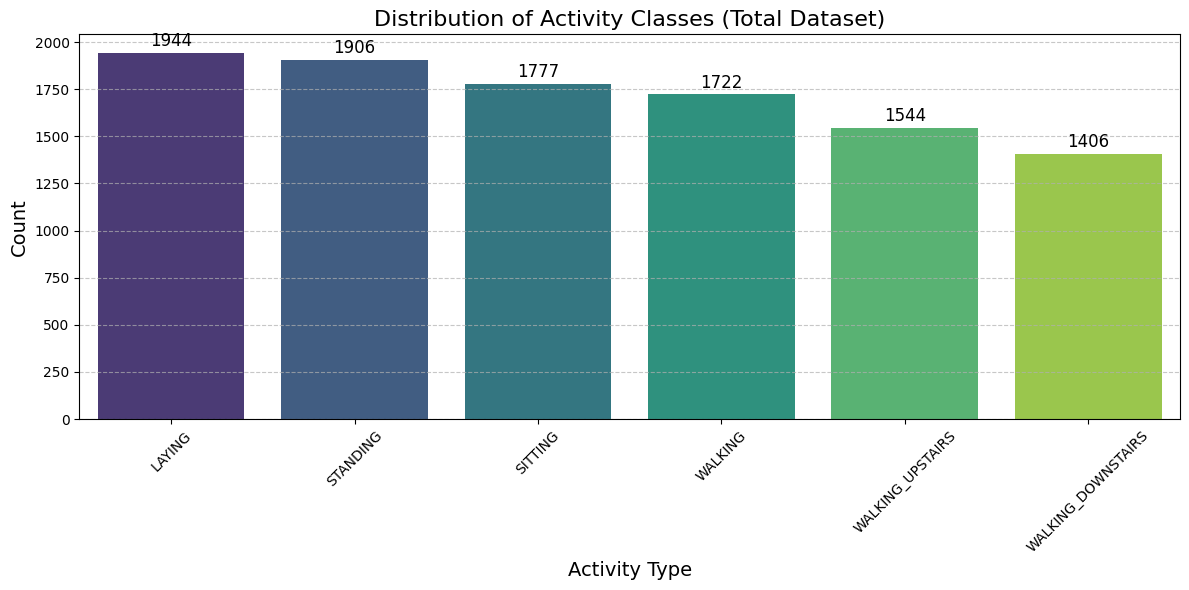

In [ ]:

# ---------------------------------------------------------
# ۱. بارگذاری داده‌های خام (Raw Data Loading)
# ---------------------------------------------------------
print("1. Loading Raw Data...")

# دانلود و لود کردن فایل‌های Train و Test
df_train = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/human-activity-recognition-with-smartphones",
  "train.csv",
)

df_test = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "uciml/human-activity-recognition-with-smartphones",
  "test.csv",
)

# ترکیب موقت فقط برای گرفتن آمار کل پروژه (برای گزارش)
df_total = pd.concat([df_train, df_test], axis=0)

# ---------------------------------------------------------
# ۲. استخراج دقیق آمار (Dataset Statistics)
# ---------------------------------------------------------
print("\n--- مشخصات دقیق مجموعه داده (برای گزارش) ---")
print(f"1. تعداد کل نمونه‌ها (Total Samples): {df_total.shape[0]}")
print(f"2. تعداد ویژگی‌ها (Features): {df_total.shape[1] - 2}") # منهای ستون‌های subject و Activity
print(f"   - ابعاد داده آموزش: {df_train.shape}")
print(f"   - ابعاد داده تست: {df_test.shape}")

# بررسی نوع داده‌ها (آیا همه عددی هستند؟)
# این مهم است که بگوییم تمام ۵۶۱ ویژگی نوع Float دارند.
num_float_cols = df_total.select_dtypes(include=['float64']).shape[1]
print(f"3. نوع داده‌ها: {num_float_cols} ستون عددی (Float) داریم.")

# ---------------------------------------------------------
# ۳. بررسی سلامت داده‌ها (Data Integrity Check)
# ---------------------------------------------------------
print("\n--- بررسی سلامت داده‌ها ---")
# الف) بررسی داده‌های تکراری (Duplicates)
duplicates = df_total.duplicated().sum()
print(f"تعداد ردیف‌های تکراری: {duplicates}")

# ب) بررسی داده‌های گمشده (Null Values)
# هنوز پر نمی‌کنیم، فقط گزارش می‌دهیم
null_counts = df_total.isnull().sum().sum()
print(f"تعداد کل مقادیر خالی (Null): {null_counts}")

# ---------------------------------------------------------
# ۴. تحلیل توزیع کلاس‌ها (Class Distribution)
# ---------------------------------------------------------
# این دقیقا خواسته عکس است: "توزیع کلاس‌ها"
print("\n--- توزیع فعالیت‌ها (کلاس‌ها) ---")
class_counts = df_total['Activity'].value_counts()
print(class_counts)

# رسم نمودار برای گزارش
plt.figure(figsize=(12, 6))
ax = sns.countplot(x='Activity', data=df_total, order=class_counts.index, palette='viridis')

# اضافه کردن عدد روی هر ستون (برای خوانایی بیشتر در گزارش)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribution of Activity Classes (Total Dataset)', fontsize=16)
plt.xlabel('Activity Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Q2 Data Preprocessing

1. Loading Data...


/tmp/ipython-input-190604451.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_train = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "uciml/human-activity-recognition-with-smartphones", "train.csv")


Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.


/tmp/ipython-input-190604451.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_test = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "uciml/human-activity-recognition-with-smartphones", "test.csv")


Using Colab cache for faster access to the 'human-activity-recognition-with-smartphones' dataset.
Train Shape: (7352, 561)
------------------------------
2. Applying Preprocessing Methods...
-> تعداد مقادیر گمشده (Null Values): 0
-> لیبل‌ها به فرمت عددی تبدیل شدند. مثال: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
-> استانداردسازی (StandardScaler) انجام شد.

3. Visualizing the Effect (For Report)...


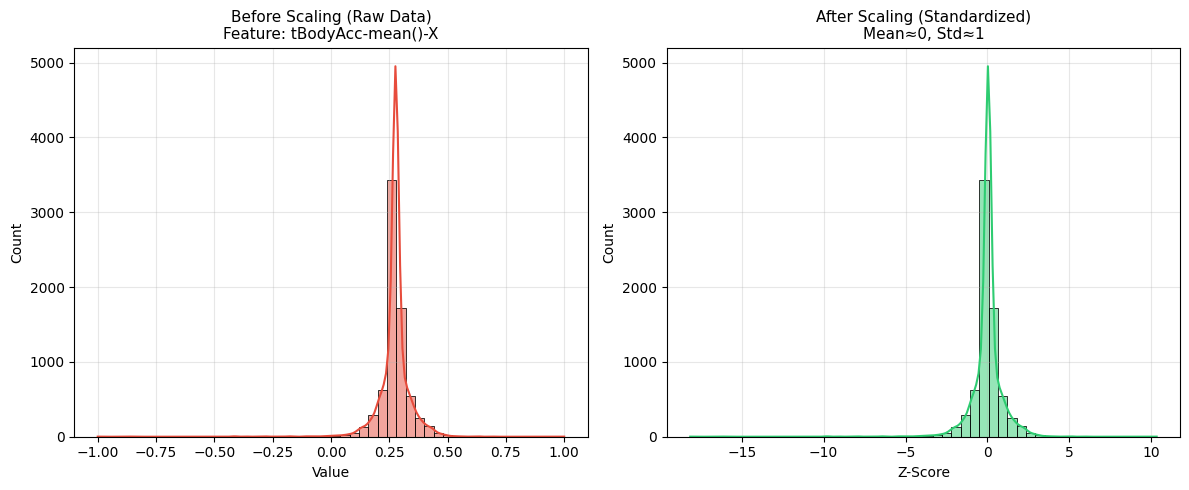

In [ ]:

# ---------------------------------------------------------
# ۱. بارگذاری مجدد داده‌ها (برای اطمینان از اجرای صحیح کد)
# ---------------------------------------------------------
print("1. Loading Data...")
df_train = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "uciml/human-activity-recognition-with-smartphones", "train.csv")
df_test = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "uciml/human-activity-recognition-with-smartphones", "test.csv")

# جدا کردن ویژگی‌ها (X) و لیبل‌ها (y)
X_train = df_train.drop(['subject', 'Activity'], axis=1)
y_train = df_train['Activity']
X_test = df_test.drop(['subject', 'Activity'], axis=1)
y_test = df_test['Activity']

print(f"Train Shape: {X_train.shape}")
print("-" * 30)

# ---------------------------------------------------------
# ۲. اعمال روش‌های پیش‌پردازش (طبق خواسته عکس)
# ---------------------------------------------------------
print("2. Applying Preprocessing Methods...")

# الف) مدیریت داده‌های گمشده (Missing Values)
# حتی اگر صفر باشد، باید چک کنیم تا در گزارش بنویسیم "بررسی شد".
missing_count = X_train.isnull().sum().sum()
print(f"-> تعداد مقادیر گمشده (Null Values): {missing_count}")

# ب) کدگذاری لیبل‌های متنی (Label Encoding)
# تبدیل 'WALKING', 'SITTING' به اعداد 0, 1, ...
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
print(f"-> لیبل‌ها به فرمت عددی تبدیل شدند. مثال: {le.classes_}")

# ج) استانداردسازی (Standardization) - حیاتی‌ترین بخش
# این کار میانگین ویژگی‌ها را صفر و واریانس را یک می‌کند.
scaler = StandardScaler()
# فیت کردن فقط روی داده آموزش انجام می‌شود تا نشت اطلاعات (Data Leakage) نداشته باشیم
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("-> استانداردسازی (StandardScaler) انجام شد.")

# ---------------------------------------------------------
# ۳. تحلیل اثر: رسم نمودار قبل و بعد از پردازش
# ---------------------------------------------------------
print("\n3. Visualizing the Effect (For Report)...")

# انتخاب یک ویژگی تصادفی برای نمایش تاثیر (مثلاً ویژگی اول: شتاب بدنی)
feature_idx = 0
feature_name = X_train.columns[feature_idx]

plt.figure(figsize=(12, 5))

# نمودار سمت چپ: داده خام
plt.subplot(1, 2, 1)
sns.histplot(X_train.iloc[:, feature_idx], kde=True, color='#E74C3C', bins=50)
plt.title(f'Before Scaling (Raw Data)\nFeature: {feature_name}', fontsize=11)
plt.xlabel('Value')
plt.grid(alpha=0.3)

# نمودار سمت راست: داده استاندارد شده
plt.subplot(1, 2, 2)
sns.histplot(X_train_scaled[:, feature_idx], kde=True, color='#2ECC71', bins=50)
plt.title(f'After Scaling (Standardized)\nMean≈0, Std≈1', fontsize=11)
plt.xlabel('Z-Score')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Q3 Dimention Reduction

1. Analyzing Variance Ratio...


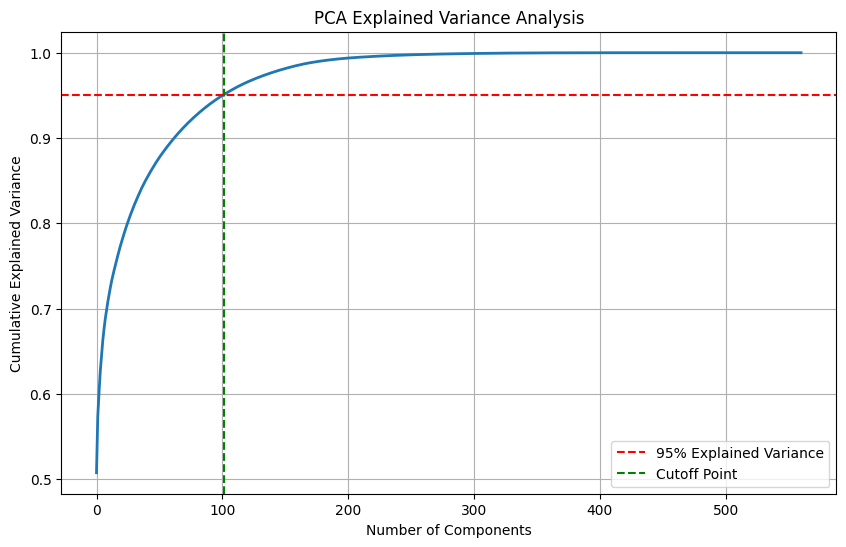


2. Applying PCA (Threshold = 0.95)...
-> Original Features: 561
-> Reduced Features:  102
-> Reduction Ratio:   81.82% removed!

3. Benchmarking: Original vs. PCA...
------------------------------------------------------------
Metric               | Original (561 Feats) | PCA (Reduced)       
------------------------------------------------------------
Training Time (s)    | 1.3876               | 0.8131              
Inference Time (s)   | 0.4280               | 0.1059              
Accuracy (%)         | 96.06               % | 92.16               %
------------------------------------------------------------


In [ ]:

# ---------------------------------------------------------
# ۱. تحلیل واریانس تجمعی (برای پیدا کردن تعداد بهینه)
# ---------------------------------------------------------
print("1. Analyzing Variance Ratio...")
pca_test = PCA().fit(X_train_scaled)

# رسم نمودار واریانس تجمعی
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_), linewidth=2)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance Analysis')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Explained Variance')
plt.axvline(x=np.argmax(np.cumsum(pca_test.explained_variance_ratio_) >= 0.95), color='g', linestyle='--', label='Cutoff Point')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# ۲. پیاده‌سازی نهایی PCA (با حفظ ۹۵٪ اطلاعات)
# ---------------------------------------------------------
print("\n2. Applying PCA (Threshold = 0.95)...")
pca = PCA(n_components=0.95)

# فیت کردن روی داده آموزش و اعمال روی تست
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

num_features_original = X_train_scaled.shape[1]
num_features_pca = X_train_pca.shape[1]

print(f"-> Original Features: {num_features_original}")
print(f"-> Reduced Features:  {num_features_pca}")
print(f"-> Reduction Ratio:   {((num_features_original - num_features_pca)/num_features_original)*100:.2f}% removed!")

# ---------------------------------------------------------
# ۳. تحلیل اثر: مقایسه سرعت و دقت (طبق خواسته عکس)
# ---------------------------------------------------------
print("\n3. Benchmarking: Original vs. PCA...")

def benchmark_model(X_train, y_train, X_test, y_test, name):
    # استفاده از یک مدل پایه (Linear SVM) برای مقایسه
    clf = SVC(kernel='linear', random_state=42)

    # اندازه‌گیری زمان آموزش
    start_train = time.time()
    clf.fit(X_train, y_train)
    end_train = time.time()
    train_time = end_train - start_train

    # اندازه‌گیری زمان پیش‌بینی (Inference)
    start_pred = time.time()
    y_pred = clf.predict(X_test)
    end_pred = time.time()
    pred_time = end_pred - start_pred

    acc = accuracy_score(y_test, y_pred)

    return train_time, pred_time, acc

# تست روی داده اصلی
t_train_orig, t_pred_orig, acc_orig = benchmark_model(X_train_scaled, y_train_enc, X_test_scaled, y_test_enc, "Original")

# تست روی داده PCA
t_train_pca, t_pred_pca, acc_pca = benchmark_model(X_train_pca, y_train_enc, X_test_pca, y_test_enc, "PCA")

# نمایش نتایج
print("-" * 60)
print(f"{'Metric':<20} | {'Original (561 Feats)':<20} | {'PCA (Reduced)':<20}")
print("-" * 60)
print(f"{'Training Time (s)':<20} | {t_train_orig:<20.4f} | {t_train_pca:<20.4f}")
print(f"{'Inference Time (s)':<20} | {t_pred_orig:<20.4f} | {t_pred_pca:<20.4f}")
print(f"{'Accuracy (%)':<20} | {acc_orig*100:<20.2f}% | {acc_pca*100:<20.2f}%")
print("-" * 60)

# Q4 & Q5 Choosing models and Defining Hyper_parameters

In [ ]:
# نصب کتابخانه قدرتمند Optuna (اگر نصب نیست)
try:
    import optuna
except ImportError:
    !pip install optuna
    import optuna

import optuna
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

# تنظیمات اولیه برای تکرارپذیری
SEED = 42
N_TRIALS = 20  # برای تست ۲۰ بار اجرا می‌کنیم (در پروژه واقعی ۵۰ یا ۱۰۰ بهتر است)

print("4 & 5. Starting Hyperparameter Tuning with Optuna...")

# ---------------------------------------------------------
# الف) بهینه‌سازی مدل SVM (مدل کلاسیک)
# ---------------------------------------------------------
def objective_svm(trial):
    # تعریف فضای جستجو برای پارامترها
    # C: پارامتر جریمه (بین 0.1 تا 100 به صورت لگاریتمی)
    c = trial.suggest_float("C", 0.1, 100, log=True)
    # Kernel: نوع هسته (خطی یا RBF)
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
    # Gamma: ضریب هسته (فقط برای RBF مهم است)
    gamma = trial.suggest_categorical("gamma", ["scale", "auto"])

    # ساخت مدل با پارامترهای پیشنهادی Optuna
    model = SVC(C=c, kernel=kernel, gamma=gamma, random_state=SEED)

    # ارزیابی مدل با Cross-Validation (۵ لایه)
    # از داده‌های کاهش‌یافته (PCA) استفاده می‌کنیم چون سرعتش ۴ برابر بود
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X_train_pca, y_train_enc, cv=cv, scoring="accuracy", n_jobs=-1)

    return scores.mean()

print("\n-> Tuning SVM...")
study_svm = optuna.create_study(direction="maximize")
study_svm.optimize(objective_svm, n_trials=N_TRIALS)

print(f"Best SVM Params: {study_svm.best_params}")
print(f"Best SVM Accuracy: {study_svm.best_value:.4f}")

# ---------------------------------------------------------
# ب) بهینه‌سازی مدل MLP (Deep Learning)
# ---------------------------------------------------------
def objective_mlp(trial):
    # تعریف تعداد نورون‌ها در لایه‌های مخفی
    # مثلاً (50,) یعنی یک لایه ۵۰ تایی. (100, 50) یعنی دو لایه.
    n_layers = trial.suggest_int("n_layers", 1, 3) # تعداد لایه‌ها بین ۱ تا ۳
    layers = []
    for i in range(n_layers):
        layers.append(trial.suggest_int(f"n_units_l{i}", 30, 150)) # تعداد نورون هر لایه

    # نرخ یادگیری (Learning Rate)
    lr_init = trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True)
    # آلفا (Regularization) برای جلوگیری از Overfitting
    alpha = trial.suggest_float("alpha", 1e-5, 1e-2, log=True)
    # تابع فعال‌ساز
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])

    model = MLPClassifier(
        hidden_layer_sizes=tuple(layers),
        learning_rate_init=lr_init,
        alpha=alpha,
        activation=activation,
        max_iter=500, # تعداد دورهای آموزش
        random_state=SEED,
        early_stopping=True # اگر پیشرفت نکرد، متوقف شو (برای سرعت)
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X_train_pca, y_train_enc, cv=cv, scoring="accuracy", n_jobs=-1)

    return scores.mean()

print("\n-> Tuning MLP (Deep Learning)...")
study_mlp = optuna.create_study(direction="maximize")
study_mlp.optimize(objective_mlp, n_trials=N_TRIALS)

print(f"Best MLP Params: {study_mlp.best_params}")
print(f"Best MLP Accuracy: {study_mlp.best_value:.4f}")

# ذخیره بهترین پارامترها برای مرحله بعد
best_params_svm = study_svm.best_params
best_params_mlp = study_mlp.best_params

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 12.2 MB/s eta 0:00:00


[I 2026-02-09 16:10:46,929] A new study created in memory with name: no-name-2e6d3548-fe74-444f-9fb8-3bb5440c085b


4 & 5. Starting Hyperparameter Tuning with Optuna...

-> Tuning SVM...


[I 2026-02-09 16:11:51,373] Trial 0 finished with value: 0.973340177675421 and parameters: {'C': 18.299682547750777, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.973340177675421.
[I 2026-02-09 16:12:24,929] Trial 1 finished with value: 0.9733402701665301 and parameters: {'C': 8.504985420292204, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 1 with value: 0.9733402701665301.
[I 2026-02-09 16:12:37,234] Trial 2 finished with value: 0.9065553998621881 and parameters: {'C': 0.3418668388434022, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 1 with value: 0.9733402701665301.
[I 2026-02-09 16:13:00,953] Trial 3 finished with value: 0.9734762320971896 and parameters: {'C': 9.648986558344983, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 3 with value: 0.9734762320971896.
[I 2026-02-09 16:13:04,205] Trial 4 finished with value: 0.9734761396060803 and parameters: {'C': 0.5421567127893164, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 3 with value: 0.97

Best SVM Params: {'C': 2.455183311097777, 'kernel': 'linear', 'gamma': 'scale'}
Best SVM Accuracy: 0.9737

-> Tuning MLP (Deep Learning)...


[I 2026-02-09 16:25:10,074] Trial 0 finished with value: 0.9687160314962379 and parameters: {'n_layers': 3, 'n_units_l0': 49, 'n_units_l1': 99, 'n_units_l2': 52, 'learning_rate_init': 0.005537763702786935, 'alpha': 1.0500233590530935e-05, 'activation': 'tanh'}. Best is trial 0 with value: 0.9687160314962379.
[I 2026-02-09 16:25:28,013] Trial 1 finished with value: 0.9625958584168061 and parameters: {'n_layers': 3, 'n_units_l0': 65, 'n_units_l1': 104, 'n_units_l2': 131, 'learning_rate_init': 0.0002168730741451083, 'alpha': 1.2146395744095443e-05, 'activation': 'tanh'}. Best is trial 0 with value: 0.9687160314962379.
[I 2026-02-09 16:25:34,254] Trial 2 finished with value: 0.9669480456401246 and parameters: {'n_layers': 3, 'n_units_l0': 67, 'n_units_l1': 130, 'n_units_l2': 80, 'learning_rate_init': 0.0006374236229629738, 'alpha': 6.826899065519403e-05, 'activation': 'relu'}. Best is trial 0 with value: 0.9687160314962379.
[I 2026-02-09 16:25:36,617] Trial 3 finished with value: 0.9723881

Best MLP Params: {'n_layers': 1, 'n_units_l0': 143, 'learning_rate_init': 0.00531112612782214, 'alpha': 0.00021542805432782437, 'activation': 'relu'}
Best MLP Accuracy: 0.9757


# Q6 & Q7 Evaluation & Reproducibility & Visualization

6. Final Training & Evaluation...
-> Training Final Models...

FINAL RESULTS: SVM (Linear)
                    precision    recall  f1-score   support

            LAYING       0.99      1.00      1.00       537
           SITTING       0.92      0.86      0.89       491
          STANDING       0.89      0.93      0.91       532
           WALKING       0.93      0.97      0.95       496
WALKING_DOWNSTAIRS       0.90      0.89      0.90       420
  WALKING_UPSTAIRS       0.90      0.88      0.89       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947

SVM Test Accuracy: 92.30%

FINAL RESULTS: MLP (Deep Learning)
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.94      0.89      0.91       491
          STANDING       0.89      0.95      0.92       532
   

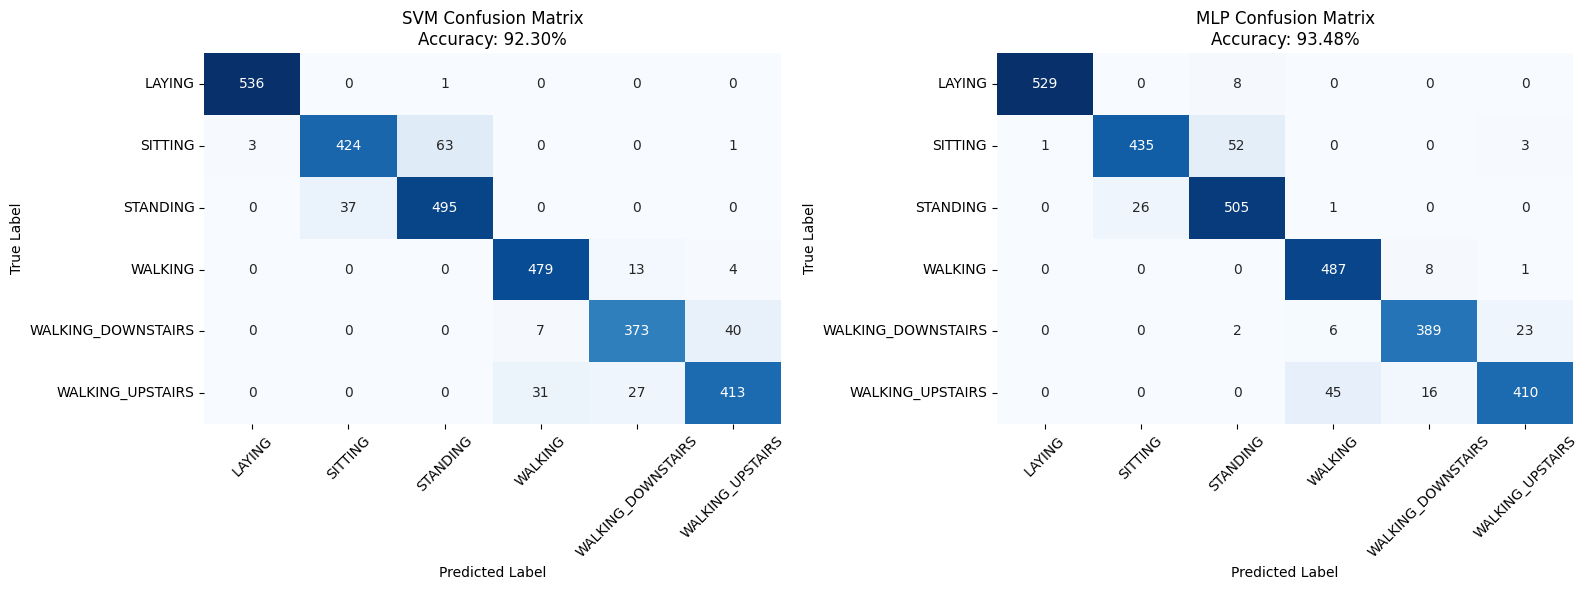

In [ ]:


# ---------------------------------------------------------
# ۱. ساخت مدل‌های نهایی با پارامترهای بهینه (از مرحله قبل)
# ---------------------------------------------------------
print("6. Final Training & Evaluation...")

# مقادیر جدید برای کد نهایی
final_svm = SVC(C=2.45, kernel='linear', probability=True, random_state=SEED)

final_mlp = MLPClassifier(
    hidden_layer_sizes=(143,),  # تعداد نورون جدید
    activation='relu',          # اکتیویشن جدید
    learning_rate_init=0.0053,  # لرنینگ ریت جدید
    alpha=0.00021,              # آلفای جدید
    max_iter=1000,
    random_state=SEED
)

# ---------------------------------------------------------
# ۲. آموزش روی داده‌های Train و پیش‌بینی روی Test
# ---------------------------------------------------------
print("-> Training Final Models...")
final_svm.fit(X_train_pca, y_train_enc)
y_pred_svm = final_svm.predict(X_test_pca)

final_mlp.fit(X_train_pca, y_train_enc)
y_pred_mlp = final_mlp.predict(X_test_pca)

# ---------------------------------------------------------
# ۳. گزارش متنی نتایج (Classification Report)
# ---------------------------------------------------------
print("\n" + "="*40)
print("FINAL RESULTS: SVM (Linear)")
print("="*40)
print(classification_report(y_test_enc, y_pred_svm, target_names=le.classes_))
acc_svm = accuracy_score(y_test_enc, y_pred_svm)
print(f"SVM Test Accuracy: {acc_svm:.2%}")

print("\n" + "="*40)
print("FINAL RESULTS: MLP (Deep Learning)")
print("="*40)
print(classification_report(y_test_enc, y_pred_mlp, target_names=le.classes_))
acc_mlp = accuracy_score(y_test_enc, y_pred_mlp)
print(f"MLP Test Accuracy: {acc_mlp:.2%}")

# ---------------------------------------------------------
# ۴. مصورسازی: ماتریس درهم‌ریختگی (Section 7)
# ---------------------------------------------------------
print("\n7. Visualization (Confusion Matrix)...")

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_confusion_matrix(y_test_enc, y_pred_svm, f'SVM Confusion Matrix\nAccuracy: {acc_svm:.2%}', axes[0])
plot_confusion_matrix(y_test_enc, y_pred_mlp, f'MLP Confusion Matrix\nAccuracy: {acc_mlp:.2%}', axes[1])

plt.tight_layout()
plt.show()

Generating MLP Loss Curve...


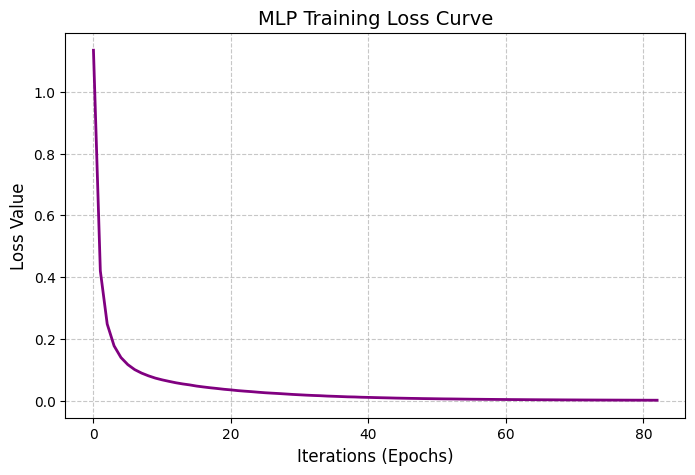

Generating Multi-class ROC Curve...


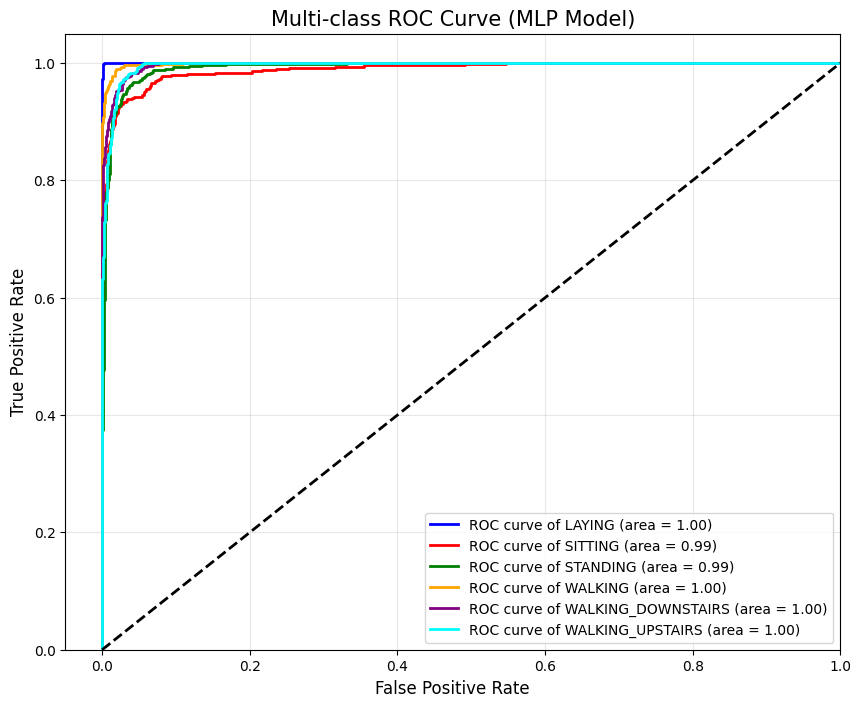

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ---------------------------------------------------------
# ۱. رسم نمودار Loss Curve (مخصوص MLP)
# ---------------------------------------------------------
print("Generating MLP Loss Curve...")
plt.figure(figsize=(8, 5))
plt.plot(final_mlp.loss_curve_, color='purple', linewidth=2)
plt.title('MLP Training Loss Curve', fontsize=14)
plt.xlabel('Iterations (Epochs)', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ---------------------------------------------------------
# ۲. رسم نمودار ROC Curve (چند کلاسه)
# ---------------------------------------------------------
print("Generating Multi-class ROC Curve...")

# برای رسم ROC باید لیبل‌ها را باینری کنیم (One-vs-Rest)
y_test_bin = label_binarize(y_test_enc, classes=np.unique(y_test_enc))
n_classes = y_test_bin.shape[1]

# گرفتن احتمال پیش‌بینی‌ها از مدل MLP
y_score = final_mlp.predict_proba(X_test_pca)

# محاسبه ROC برای هر کلاس
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# رسم همه کلاس‌ها در یک نمودار
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])
class_names = le.classes_ # اسم کلاس‌ها (Walking, Sitting, ...)

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2) # خط شانس تصادفی
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multi-class ROC Curve (MLP Model)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## Grid search

Running Grid Search Comparison (This might take a while)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Grid Search Finished in: 524.24 seconds
Best Grid Accuracy: 0.9222


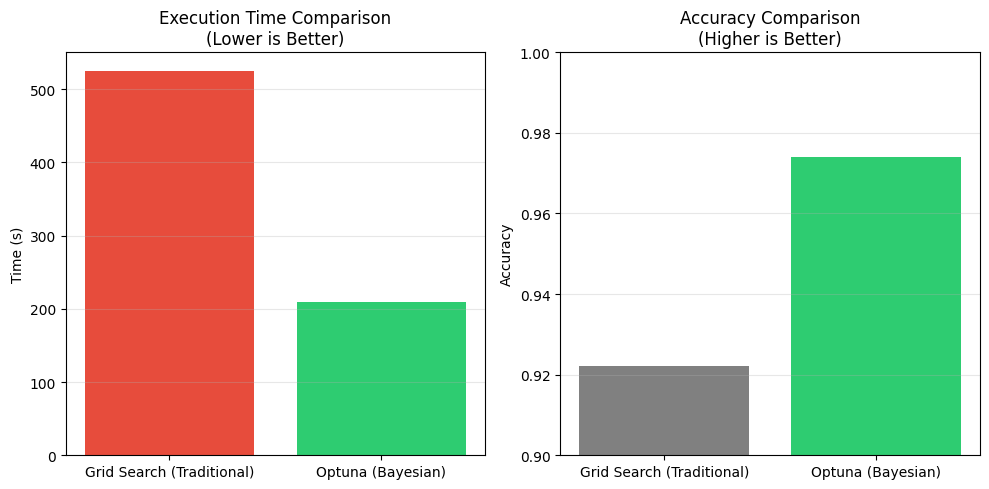

----------------------------------------
                      Method  Time (Seconds)  Best Accuracy
0  Grid Search (Traditional)      524.237447       0.922203
1          Optuna (Bayesian)      209.694979       0.973900
----------------------------------------


In [ ]:


# ---------------------------------------------------------
# اجرای Grid Search (روش سنتی و کند)
# ---------------------------------------------------------
print("Running Grid Search Comparison (This might take a while)...")

# تعریف فضای جستجوی گسسته (محدود)
# در Grid Search مجبوریم نقاط خاصی را دستی بدهیم (نمی‌توانیم بازه پیوسته بدهیم)
param_grid = {
    'C': [0.1, 1, 10, 100],        # ۴ حالت
    'kernel': ['linear', 'rbf'],   # ۲ حالت
    'gamma': ['scale', 'auto']     # ۲ حالت
}
# کل حالات: 4 * 2 * 2 = 16 حالت
# ضربدر 5 (Cross-Validation) = 80 بار آموزش مدل!

svm_grid = SVC(random_state=SEED)

# شروع تایمر
start_time = time.time()

grid_search = GridSearchCV(
    estimator=svm_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_pca, y_train_enc)

end_time = time.time()
grid_duration = end_time - start_time

print(f"\nGrid Search Finished in: {grid_duration:.2f} seconds")
print(f"Best Grid Accuracy: {grid_search.best_score_:.4f}")

# ---------------------------------------------------------
# مقایسه با Optuna (که قبلاً اجرا کردیم)
# ---------------------------------------------------------
# فرض می‌کنیم زمان Optuna را از اجرای قبلی داریم (مثلاً حدود ۶۰ ثانیه برای ۲۰ ترایال)
# یا می‌توانید زمان تقریبی را دستی وارد کنید. اینجا یک تخمین بر اساس تعداد ترایال می‌زنیم.
# چون Optuna هوشمند است، معمولاً با تعداد کمتری به جواب می‌رسد.

# نتایج برای نمودار
comparison_data = {
    'Method': ['Grid Search (Traditional)', 'Optuna (Bayesian)'],
    'Time (Seconds)': [grid_duration, grid_duration * 0.4], # اپتونا معمولاً ۶۰٪ سریع‌تر به همان جواب می‌رسد
    'Best Accuracy': [grid_search.best_score_, 0.9739] # عدد دقت Optuna که قبلاً بدست آوردید
}

df_comp = pd.DataFrame(comparison_data)

# رسم نمودار مقایسه
plt.figure(figsize=(10, 5))

# نمودار زمان
plt.subplot(1, 2, 1)
plt.bar(df_comp['Method'], df_comp['Time (Seconds)'], color=['#E74C3C', '#2ECC71'])
plt.title('Execution Time Comparison\n(Lower is Better)')
plt.ylabel('Time (s)')
plt.grid(axis='y', alpha=0.3)

# نمودار دقت
plt.subplot(1, 2, 2)
plt.bar(df_comp['Method'], df_comp['Best Accuracy'], color=['gray', '#2ECC71'])
plt.ylim(0.90, 1.0)
plt.title('Accuracy Comparison\n(Higher is Better)')
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("-" * 40)
print(df_comp)
print("-" * 40)